### Calculating fingerprint measure - ie distributions of on/off diagonal diff

In [1]:
import os
os.chdir("/home/anna-beer/Documents/anna_phd/Canonical-HMM-Networks") #sets working directory to the repo, so that all imports work correctly
print(os.getcwd())
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict



/home/anna-beer/Documents/anna_phd/Canonical-HMM-Networks


In [2]:
def diag_diff_func(corr_mat):
    on_diagonal_ave_list = []
    off_diagonal_ave_list = []

    on_diagonal = []
    off_diagonal = []
    
    for i in range(15):
        for j in range(15):
            val = corr_mat[i][j]
            if i==j: 
                on_diagonal.append(val)
            if i!=j:
                off_diagonal.append(val)


    on_diagonal_ave = np.mean(on_diagonal)
    off_diagonal_ave = np.mean(off_diagonal)
    on_diagonal_ave_list.append(on_diagonal_ave)
    off_diagonal_ave_list.append(off_diagonal_ave)
        
    on_diagonal_ave_list = np.array(on_diagonal_ave_list)
    off_diagonal_ave_list = np.array(off_diagonal_ave_list)
    diag_diff = on_diagonal_ave_list - off_diagonal_ave_list

    return diag_diff

def shuffle_func(mat):
    flat = mat.flatten()
    np.random.shuffle(flat)
    shuffled_matrix = flat.reshape(15, 15)

    return shuffled_matrix

def shuffled_diag_diff(corr_mat):
    on_diagonal_ave_list = []
    off_diagonal_ave_list = []
    
    corr_mat_shuffled = shuffle_func(corr_mat)

    on_diagonal = []
    off_diagonal = []
    for i in range(15):
        for j in range(15):
            val = corr_mat_shuffled[i][j]
            if i==j: 
                on_diagonal.append(val)
            if i!=j:
                off_diagonal.append(val)
    

    on_diagonal_ave = np.mean(on_diagonal)
    off_diagonal_ave = np.mean(off_diagonal)
    on_diagonal_ave_list.append(on_diagonal_ave)
    off_diagonal_ave_list.append(off_diagonal_ave)

    on_diagonal_ave_list = np.array(on_diagonal_ave_list)
    off_diagonal_ave_list = np.array(off_diagonal_ave_list)
    diag_diff = on_diagonal_ave_list - off_diagonal_ave_list

    return diag_diff

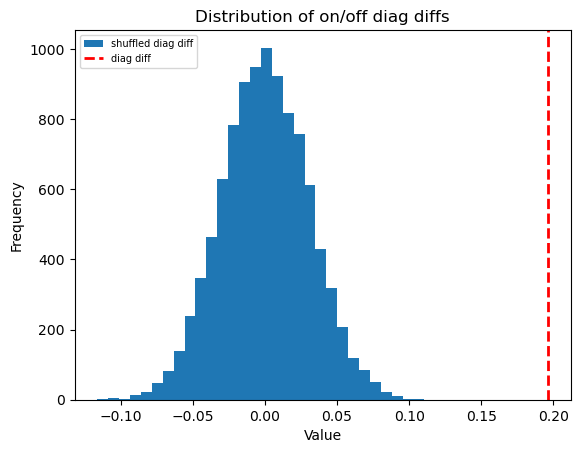

In [7]:
#load in matrices...
base = "/rdrives/DRS-foundation-brain/zoe_data/BIDS"
deriv = f"{base}/derivatives_anna_01042026"
corr_dir = f"{deriv}/correlations_matrices/OPM_SQUID_noorthog"


OPM_trial_timeseries = np.load(f'{corr_dir}/OPM1_OPM2_trial_timeseries.npy')


diag_diff = diag_diff_func(OPM_trial_timeseries)

diag_diffs_shuffled = []
for i in range(10000):
    diag_diffs_shuff = shuffled_diag_diff(OPM_trial_timeseries)
    diag_diffs_shuffled.append(diag_diffs_shuff)
diag_diffs_shuffled = np.array(diag_diffs_shuffled)

fig = plt.figure()
plt.hist(diag_diffs_shuffled[:,0], bins=30, label='shuffled diag diff')
plt.axvline(x=diag_diff[0], color='red', linestyle='--', linewidth=2, label='diag diff')
plt.legend(prop={'size': 7})
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Distribution of on/off diag diffs")
plt.show()

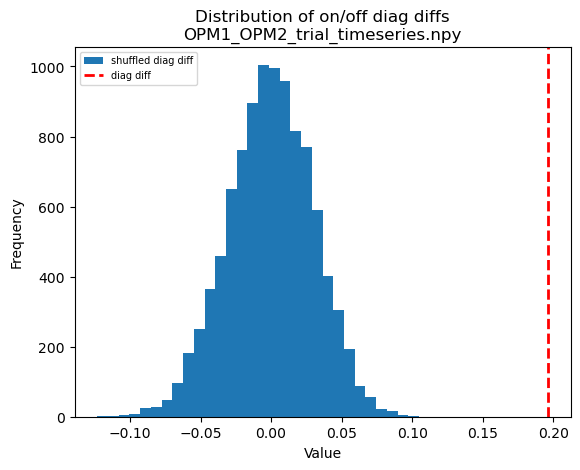

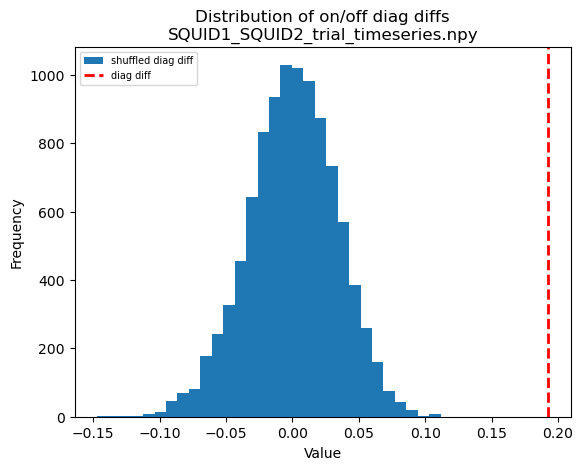

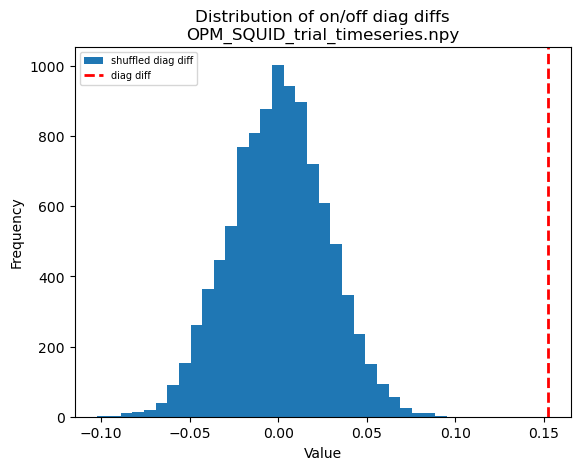

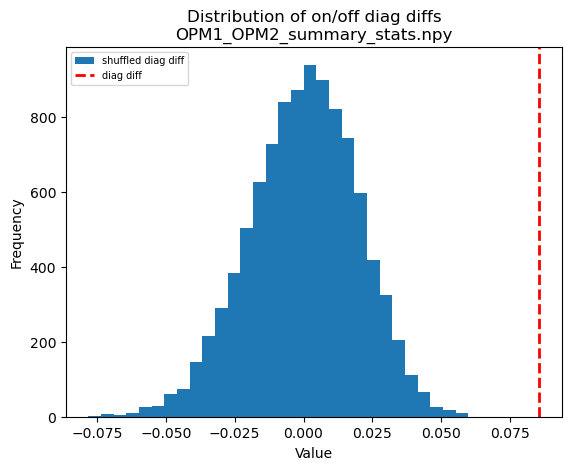

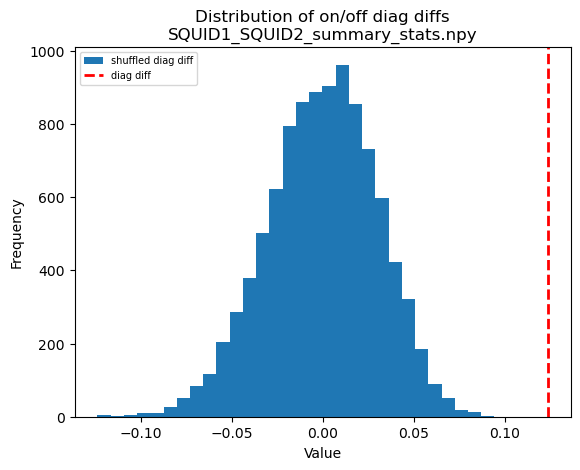

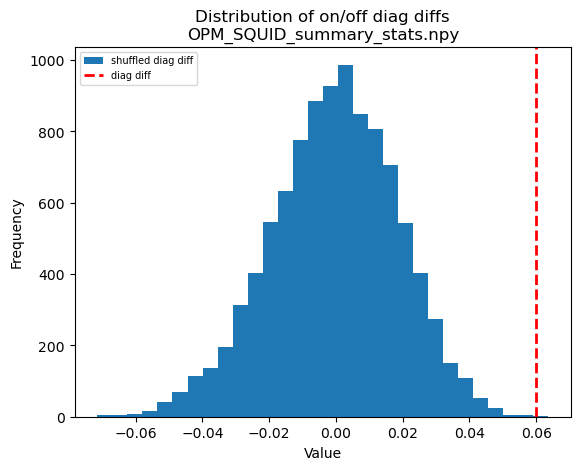

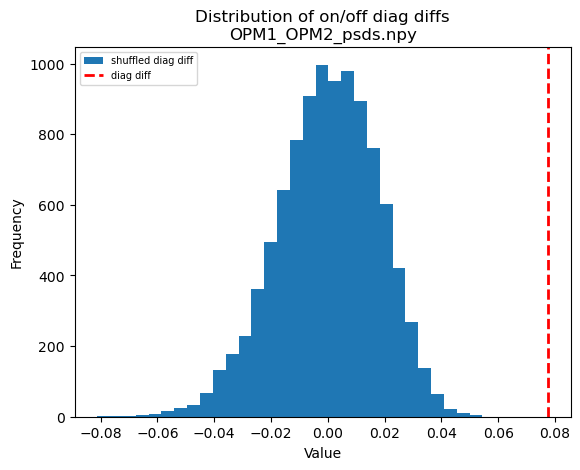

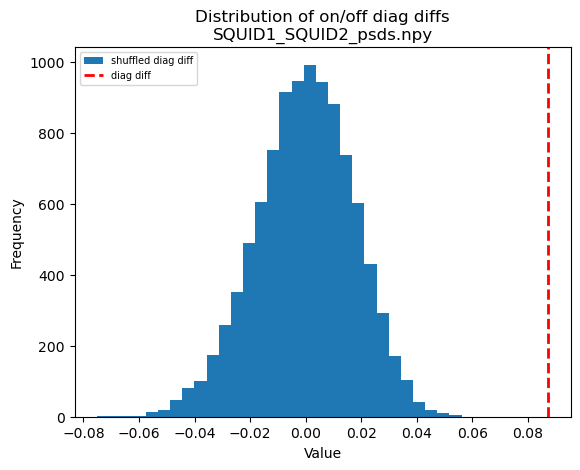

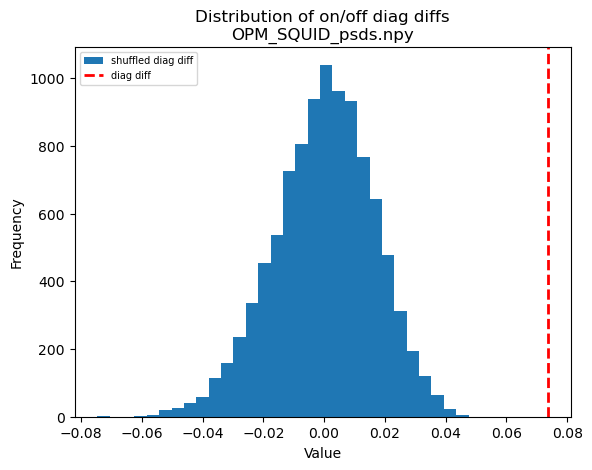

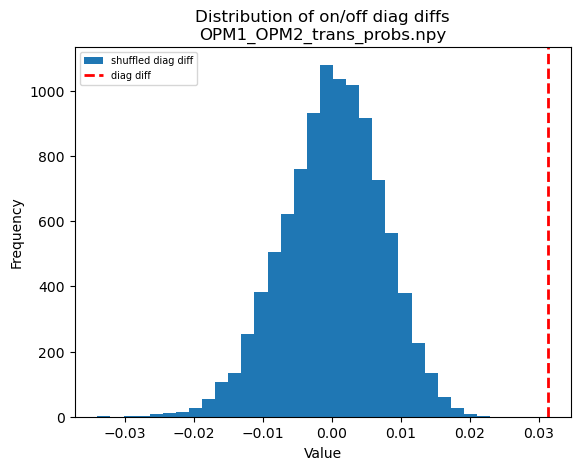

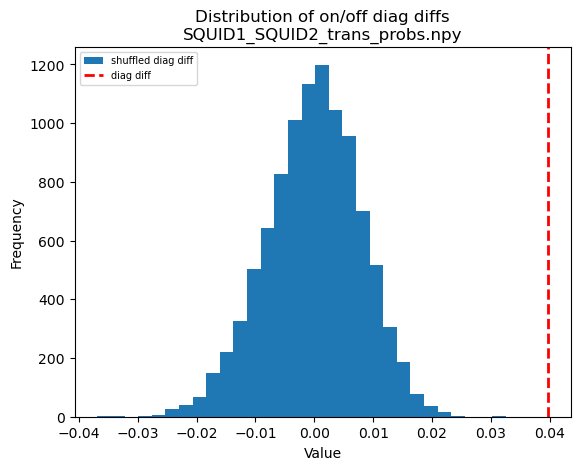

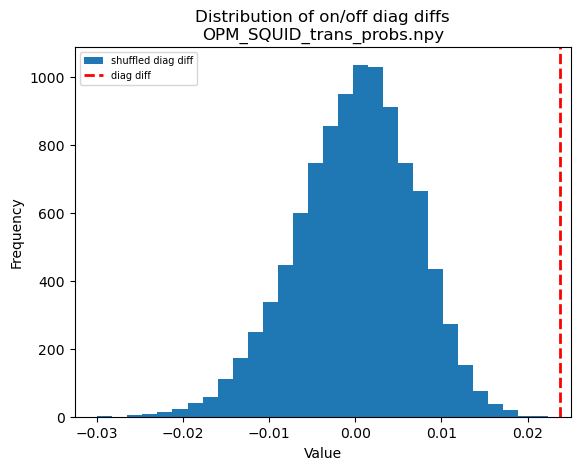

In [ ]:
# import os
# import numpy as np
# import matplotlib.pyplot as plt

# base = "/rdrives/DRS-foundation-brain/zoe_data/BIDS"
# deriv = f"{base}/derivatives_anna_01042026"
# corr_dir = f"{deriv}/correlations_matrices/OPM_SQUID_noorthog"

# # Get all numpy files in directory
# npy_files = [f for f in os.listdir(corr_dir) if f.endswith(".npy")]

# for npy_file in npy_files:
#     file_path = os.path.join(corr_dir, npy_file)
    
#     # Load data
#     corr_mat = np.load(file_path)

#     # Compute real diag diff
#     diag_diff = diag_diff_func(corr_mat)

#     # Compute shuffled distribution
#     diag_diffs_shuffled = []
#     for i in range(10000):
#         diag_diffs_shuff = shuffled_diag_diff(corr_mat)
#         diag_diffs_shuffled.append(diag_diffs_shuff)
#     diag_diffs_shuffled = np.array(diag_diffs_shuffled)

#     # Plot
#     plt.figure()
#     plt.hist(diag_diffs_shuffled[:, 0], bins=30, label='shuffled diag diff')
#     plt.axvline(x=diag_diff[0], color='red', linestyle='--', linewidth=2, label='diag diff')
#     plt.legend(prop={'size': 7})
#     plt.xlabel("Value")
#     plt.ylabel("Frequency")
#     plt.title(f"Distribution of on/off diag diffs\n{npy_file}")

    # Save figure
    # save_name = npy_file.replace(".npy", "_onoff_diag_diff.png")
    # save_path = os.path.join(corr_dir, save_name)
    # plt.savefig(save_path, dpi=300, bbox_inches='tight')

    # plt.close()  # important to avoid memory issues

    # print(f"Saved: {save_path}")

In [5]:
base = "/rdrives/DRS-foundation-brain/zoe_data/BIDS"
deriv = f"{base}/derivatives_anna_01042026"
corr_dir = f"{deriv}/correlations_matrices/OPM_SQUID_orthog"

corr_fig_dir = f"{deriv}/correlation_figures/on_off_diag_diffs"
os.makedirs(corr_fig_dir, exist_ok=True)  # create directory if it doesn't exist

# Get all numpy files
npy_files = [f for f in os.listdir(corr_dir) if f.endswith(".npy")]

# Group files by last 4 characters before .npy
groups = defaultdict(list)
for f in npy_files:
    key = f.replace(".npy", "")[-4:]
    groups[key].append(f)

for key, files in groups.items():
    print(f"Processing group: {key}")

    group_results = []

    # -------- First pass: compute all values --------
    for npy_file in files:
        file_path = os.path.join(corr_dir, npy_file)
        data = np.load(file_path)

        diag_diff = diag_diff_func(data)

        diag_diffs_shuffled = []
        for i in range(10000):
            diag_diffs_shuffled.append(shuffled_diag_diff(data))
        diag_diffs_shuffled = np.array(diag_diffs_shuffled)

        group_results.append({
            "file": npy_file,
            "diag_diff": diag_diff,
            "shuffled": diag_diffs_shuffled
        })

    # -------- Determine shared x-range --------
    all_values = []
    for res in group_results:
        all_values.extend(res["shuffled"][:, 0])
        all_values.append(res["diag_diff"][0])

    xmin = np.min(all_values)
    xmax = np.max(all_values)

    # Optional: add a small margin
    margin = 0.05 * (xmax - xmin)
    xmin -= margin
    xmax += margin

    # -------- Second pass: plot with shared range --------
    for res in group_results:
        npy_file = res["file"]
        diag_diff = res["diag_diff"]
        diag_diffs_shuffled = res["shuffled"]

        plt.figure()
        plt.hist(
            diag_diffs_shuffled[:, 0],
            bins=50,
            range=(xmin, xmax),
            label='shuffled diag diff' 
        )
        plt.axvline(
            x=diag_diff[0],
            color='red',
            linestyle='--',
            linewidth=2,
            label=f"diag diff = {diag_diff[0]:.3f}"
        )

        plt.xlim(xmin, xmax)
        plt.legend(prop={'size': 7})
        plt.xlabel("On/off diag correlation difference")
        plt.ylabel("Frequency")
        plt.title(f"{npy_file.replace('.npy', '\nCorrelation matrix on/off diagonal difference')}")

        save_name = npy_file.replace(".npy", "_onoff_diag_diff.png")
        save_path = os.path.join(corr_fig_dir, save_name)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()

        print(f"Saved: {save_path}")

Processing group: ries
Saved: /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/correlation_figures/on_off_diag_diffs/OPM1_OPM2_trial_timeseries_onoff_diag_diff.png
Saved: /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/correlation_figures/on_off_diag_diffs/SQUID1_SQUID2_trial_timeseries_onoff_diag_diff.png
Saved: /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/correlation_figures/on_off_diag_diffs/OPM_SQUID_trial_timeseries_onoff_diag_diff.png
Processing group: tats
Saved: /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/correlation_figures/on_off_diag_diffs/OPM1_OPM2_summary_stats_onoff_diag_diff.png
Saved: /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/correlation_figures/on_off_diag_diffs/SQUID1_SQUID2_summary_stats_onoff_diag_diff.png
Saved: /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/correlation_figures/on_off_diag_diffs/OPM_SQUID_summary_stats_ono